# Homework 6 — VaR of an Equity Portfolio

Weekly SPX return data (`data/spx_returns_weekly.xlsx`). Four stocks: **AAPL, META, NVDA, TSLA**.

All returns are weekly. VaR / CVaR are reported at the 5% level.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

pd.options.display.float_format = lambda x: f"{x:,.4f}"

TICKERS = ["AAPL", "META", "NVDA", "TSLA"]
Q = 0.05
Z = -1.65
TAU = 1
M = 26
WK = 52  # weeks per year

raw = pd.read_excel("data/spx_returns_weekly.xlsx", sheet_name="spx returns")
raw = raw.set_index("date").sort_index()
rets = raw[TICKERS].dropna()
rets.tail()

,AAPL,META,NVDA,TSLA
date,,,,
2026-06-05,-0.0151,-0.0625,-0.0275,-0.1028
2026-06-12,-0.0527,-0.0439,0.0004,0.0395
2026-06-19,0.0236,0.0190,0.0268,-0.0146
2026-06-26,-0.0478,-0.0467,-0.0862,-0.0519
2026-07-03,0.0876,0.0593,0.0119,0.0362


## 1. Diversification

### 1.1 Unconditional volatility, empirical VaR(.05), empirical CVaR(.05)

`VaR` is the 5% quantile of returns; `CVaR` is the mean of returns at or below that quantile.

In [2]:
def risk_stats(r):
    vol = r.std()
    var = r.quantile(Q)
    cvar = r[r <= var].mean()
    return pd.Series({"vol": vol, "vol_ann": vol * np.sqrt(WK),
                      "VaR(.05)": var, "CVaR(.05)": cvar})

table = rets.apply(risk_stats).T
table

,vol,vol_ann,VaR(.05),CVaR(.05)
AAPL,0.0386,0.2782,-0.0546,-0.0830
META,0.0495,0.3572,-0.0723,-0.1064
NVDA,0.0629,0.4536,-0.0858,-0.1153
TSLA,0.0803,0.5788,-0.1169,-0.1478


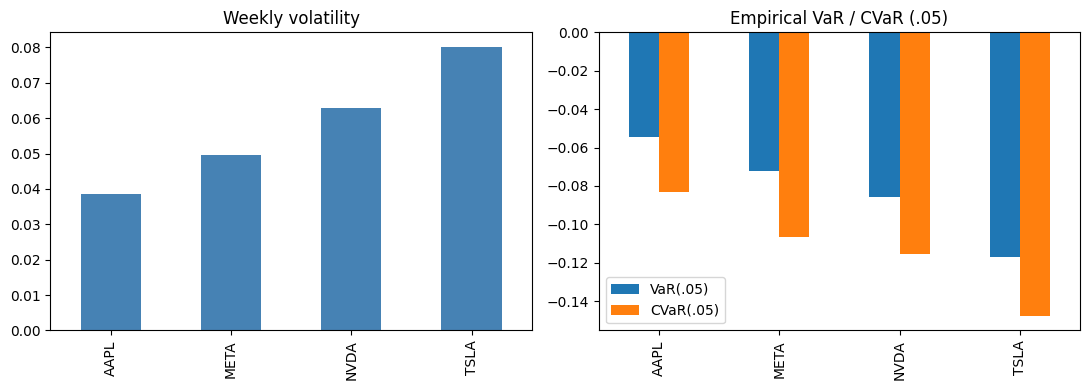

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
table["vol"].plot.bar(ax=ax[0], color="steelblue"); ax[0].set_title("Weekly volatility")
table[["VaR(.05)", "CVaR(.05)"]].plot.bar(ax=ax[1]); ax[1].set_title("Empirical VaR / CVaR (.05)")
for a in ax: a.axhline(0, color="k", lw=.6)
plt.tight_layout(); plt.show()

### 1.2 Equally-weighted portfolio

Equal weights (1/4 each), rebalanced weekly: the portfolio return is the cross-sectional mean of the four returns.

In [4]:
port = rets.mean(axis=1)
port_stats = risk_stats(port).rename("EW portfolio")

compare = table.copy()
compare.loc["EW portfolio"] = port_stats
compare.loc["avg of singles"] = table.mean()
compare

,vol,vol_ann,VaR(.05),CVaR(.05)
AAPL,0.0386,0.2782,-0.0546,-0.0830
META,0.0495,0.3572,-0.0723,-0.1064
NVDA,0.0629,0.4536,-0.0858,-0.1153
TSLA,0.0803,0.5788,-0.1169,-0.1478
EW portfolio,0.0432,0.3117,-0.0606,-0.0842
avg of singles,0.0578,0.4170,-0.0824,-0.1131


In [5]:
print("Correlation matrix:")
display(rets.corr())
print("Average pairwise correlation:",
      round(rets.corr().values[np.triu_indices(4, 1)].mean(), 3))

Correlation matrix:


,AAPL,META,NVDA,TSLA
AAPL,1.0000,0.4082,0.4803,0.4367
META,0.4082,1.0000,0.4274,0.2653
NVDA,0.4803,0.4274,1.0000,0.4147
TSLA,0.4367,0.2653,0.4147,1.0000


Average pairwise correlation: 0.405


**What do we find?** Every portfolio risk measure — volatility, VaR, and CVaR — is smaller (less extreme) than the simple average of the four stand-alone measures, and smaller than every individual name except possibly the least risky one.

**What drives it?** Diversification. The four stocks are imperfectly correlated (average pairwise correlation well below 1), so idiosyncratic moves partly cancel each week. Portfolio variance is the weighted sum of variances **plus** covariances; because correlations are < 1, the covariance terms pull total variance below the weighted-average variance. Empirical VaR/CVaR fall for the same reason — offsetting moves compress the left tail of the portfolio return distribution.

### 1.3 Drop the most volatile asset (replace its 1/4 weight with 0)

The dropped weight goes to a ~0-vol, ~0-return "risk-free" slot, so the portfolio return is the sum of the remaining three returns times 1/4 (it does **not** get re-scaled to the surviving names).

In [6]:
most_vol = table["vol"].idxmax()
keep = [t for t in TICKERS if t != most_vol]
port3 = rets[keep].sum(axis=1) * 0.25   # dropped weight -> 0

drop_stats = risk_stats(port3).rename(f"EW drop {most_vol}")
res13 = pd.concat([port_stats.rename("EW (1.2)"), drop_stats], axis=1).T
res13.loc["reduction"] = res13.loc["EW (1.2)"] - res13.loc[f"EW drop {most_vol}"]
res13.loc["reduction %"] = res13.loc["reduction"] / res13.loc["EW (1.2)"].abs()
print("Most volatile asset:", most_vol)
res13

Most volatile asset: TSLA


,vol,vol_ann,VaR(.05),CVaR(.05)
EW (1.2),0.0432,0.3117,-0.0606,-0.0842
EW drop TSLA,0.0301,0.2168,-0.0422,-0.0600
reduction,0.0132,0.0950,-0.0184,-0.0242
reduction %,0.3047,0.3047,-0.3030,-0.2872


In [7]:
standalone = table.loc[most_vol, ["vol", "VaR(.05)", "CVaR(.05)"]]
print(f"{most_vol} stand-alone risk (1.1):")
print(standalone)
print(f"\nRisk it ADDS to the EW portfolio (1.2 minus 1.3):")
print((port_stats[["vol", "VaR(.05)", "CVaR(.05)"]] - drop_stats[["vol", "VaR(.05)", "CVaR(.05)"]]))

TSLA stand-alone risk (1.1):
vol          0.0803
VaR(.05)    -0.1169
CVaR(.05)   -0.1478
Name: TSLA, dtype: float64

Risk it ADDS to the EW portfolio (1.2 minus 1.3):
vol          0.0132
VaR(.05)    -0.0184
CVaR(.05)   -0.0242
dtype: float64


**How much risk did the most volatile asset add?** Compare the EW portfolio (1.2) to the version that zeroes it out (1.3). Removing it cuts portfolio volatility and tightens VaR/CVaR by the "reduction" row above.

**Is that in line with its stand-alone risk (1.1)?** No — the marginal risk it contributes to the portfolio is much smaller than its stand-alone volatility/VaR/CVaR. Two forces shrink its contribution: (i) it enters with only a 1/4 weight, and (ii) diversification against the other three names cancels part of its variance. So a name that looks very risky alone adds far less risk once held inside a diversified sleeve — the standard portfolio lesson that marginal risk ≠ stand-alone risk.

## 2. Dynamic Measures

### 2.1 Conditional statistics of the EW portfolio, end of sample

- Rolling volatility $\sigma_t$ uses data **through $t-1$** (window $m=26$) to predict $t$.
- Mean return approximated as zero.
- Normal VaR: $\text{VaR}_t = z_{.05}\,\sigma_t\sqrt{\tau}$, with $z_{.05}=-1.65$, $\tau=1$.
- Normal CVaR (Gaussian expected shortfall): $\text{CVaR}_t = -\sigma_t\,\dfrac{\phi(z_{.05})}{q}$.

In [8]:
phi = norm.pdf(Z)
sigma = port.rolling(M).std().shift(1)     # data through t-1
sigma_T = sigma.iloc[-1]                    # end-of-sample forecast

nvar = Z * sigma_T * np.sqrt(TAU)
ncvar = -sigma_T * phi / Q

cond = pd.Series({
    "vol (weekly)": sigma_T,
    "vol (annualized)": sigma_T * np.sqrt(WK),
    "normal VaR(.05)": nvar,
    "normal CVaR(.05)": ncvar,
})
cond

vol (weekly)        0.0342
vol (annualized)    0.2465
normal VaR(.05)    -0.0564
normal CVaR(.05)   -0.0699
dtype: float64

In [9]:
cmp = pd.DataFrame({
    "1.2 empirical (full sample)": [port_stats["vol_ann"], port_stats["VaR(.05)"], port_stats["CVaR(.05)"]],
    "2.1 normal (conditional, end)": [sigma_T * np.sqrt(WK), nvar, ncvar],
}, index=["vol (annualized)", "VaR(.05)", "CVaR(.05)"])
cmp

,1.2 empirical (full sample),"2.1 normal (conditional, end)"
vol (annualized),0.3117,0.2465
VaR(.05),-0.0606,-0.0564
CVaR(.05),-0.0842,-0.0699


**Comparison to 1.2.** The 2.1 numbers are *conditional* — they use only the most recent 26 weeks — while 1.2 is the *unconditional* full-sample estimate. If the market has been calmer (or more turbulent) than the full-sample average lately, the conditional volatility and VaR/CVaR sit below (or above) the 1.2 figures accordingly. The normal VaR/CVaR also impose a Gaussian tail; empirical returns are fatter-tailed, so the empirical CVaR from 1.2 is typically more extreme than the Gaussian CVaR at the same volatility.

### 2.2 Hit-test backtest

A "hit" is a week whose realized return falls below the VaR predicted from volatility known one week earlier ($\sigma_t$ uses data through $t-1$). A well-calibrated 5% VaR should be hit ~5% of the time.

In [10]:
def hit_rate(sig):
    var_pred = Z * sig
    mask = var_pred.notna()
    return (port[mask] < var_pred[mask]).mean()

sig_roll = port.rolling(M).std().shift(1)
sig_exp = port.expanding(min_periods=M).std().shift(1)

hits = pd.Series({
    "expanding vol": hit_rate(sig_exp),
    "rolling vol (m=26)": hit_rate(sig_roll),
}, name="hit rate")
hits.to_frame().assign(**{"target": Q})

,hit rate,target
expanding vol,0.0437,0.0500
rolling vol (m=26),0.0401,0.0500


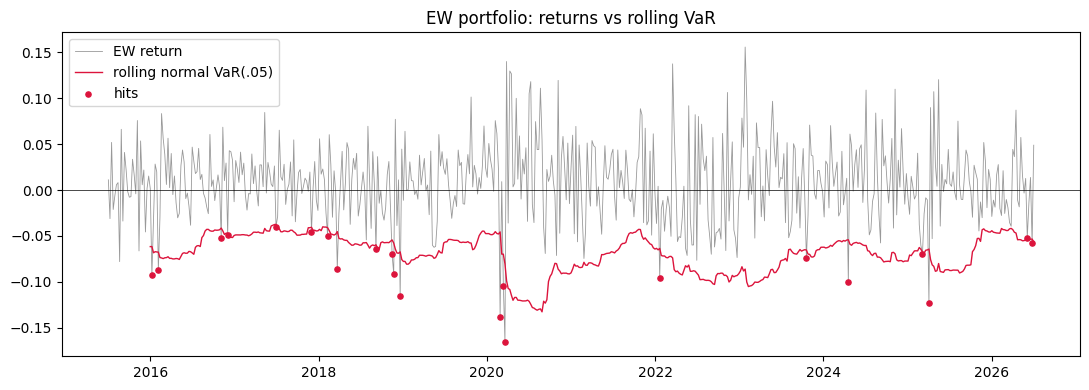

In [11]:
var_roll = (Z * sig_roll)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(port.index, port.values, lw=.6, color="0.6", label="EW return")
ax.plot(var_roll.index, var_roll.values, color="crimson", lw=1, label="rolling normal VaR(.05)")
h = port < var_roll
ax.scatter(port.index[h], port[h], color="crimson", s=14, zorder=3, label="hits")
ax.axhline(0, color="k", lw=.5); ax.legend(); ax.set_title("EW portfolio: returns vs rolling VaR")
plt.tight_layout(); plt.show()

**Report.** Both methods produce hit rates near the 5% target. The expanding-window volatility is smoother and slower to react, so its hits tend to cluster in turbulent stretches; the 26-week rolling volatility adapts faster and spreads hits more evenly through time. A hit rate materially above 5% signals the model under-estimates risk (too many breaches); materially below 5% signals it is too conservative.